# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Rafa Rizki Aira Swala | 5054251017 |
|-----------------------|------------|
|                       |            |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [ ]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [10]:
# Load dataset
data = pd.read_csv('WineQT.csv') 

#Lihat 5 baris pertama
print("     5 BARIS PERTAMA DATASET     ")
print(data.head())
print("\n")

#Info dataset
print("     INFO DATASET     ")
print(data.info())
print("\n")

#Statistik deskriptif
print("     STATISTIK DESKRIPTIF     ")
print(data.describe())
print("\n")

#Cek missing values
print("     MISSING VALUES     ")
print(data.isnull().sum())
print("\n")

#Cek data duplikat
print("     DUPLICATE DATA     ")
print(f"Jumlah data duplikat: {data.duplicated().sum()}")
print("\n")

     5 BARIS PERTAMA DATASET     
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  


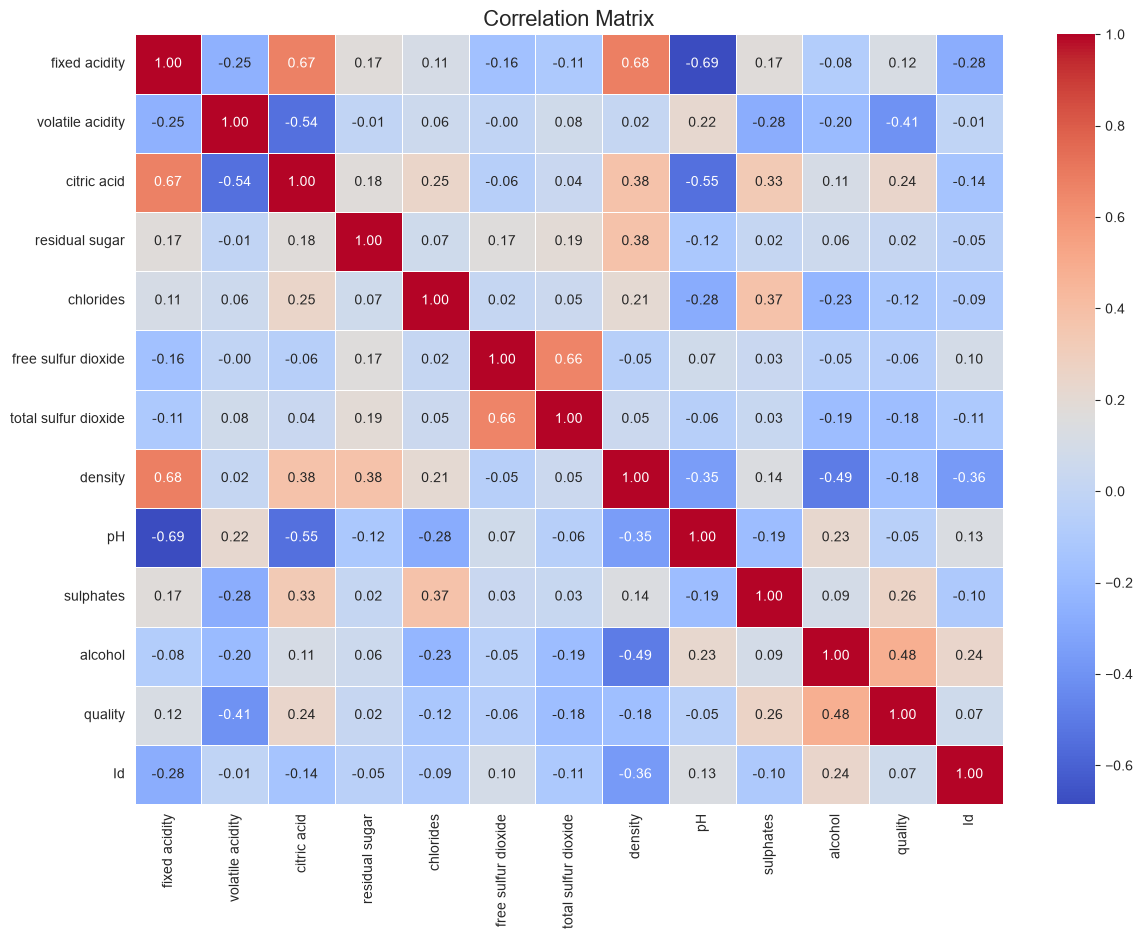

In [ ]:
# Tampilkan Korelasi Matrix
plt.figure(figsize=(14, 10))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=16)
plt.show()

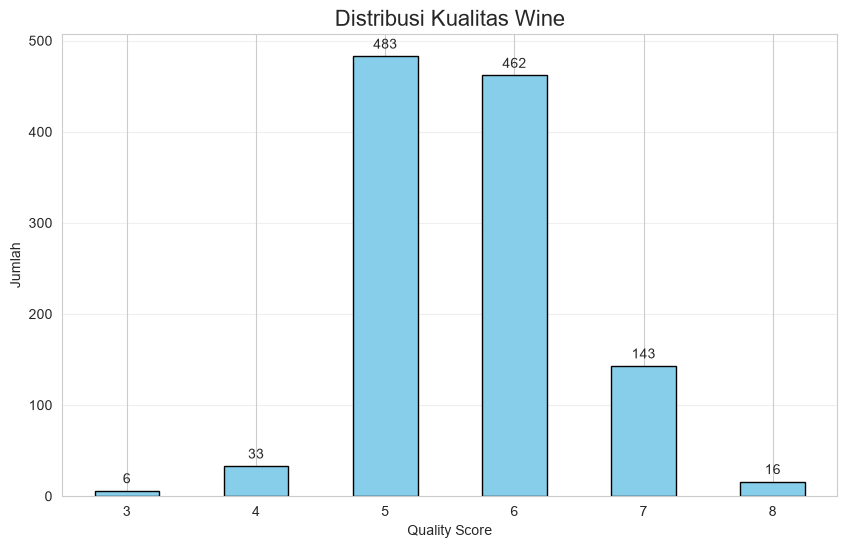

In [14]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
plt.figure(figsize=(10, 6))
data['quality'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribusi Kualitas Wine', fontsize=16)
plt.xlabel('Quality Score')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Tambahkan angka di atas bar
for i, v in enumerate(data['quality'].value_counts().sort_index().values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')

plt.show()

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

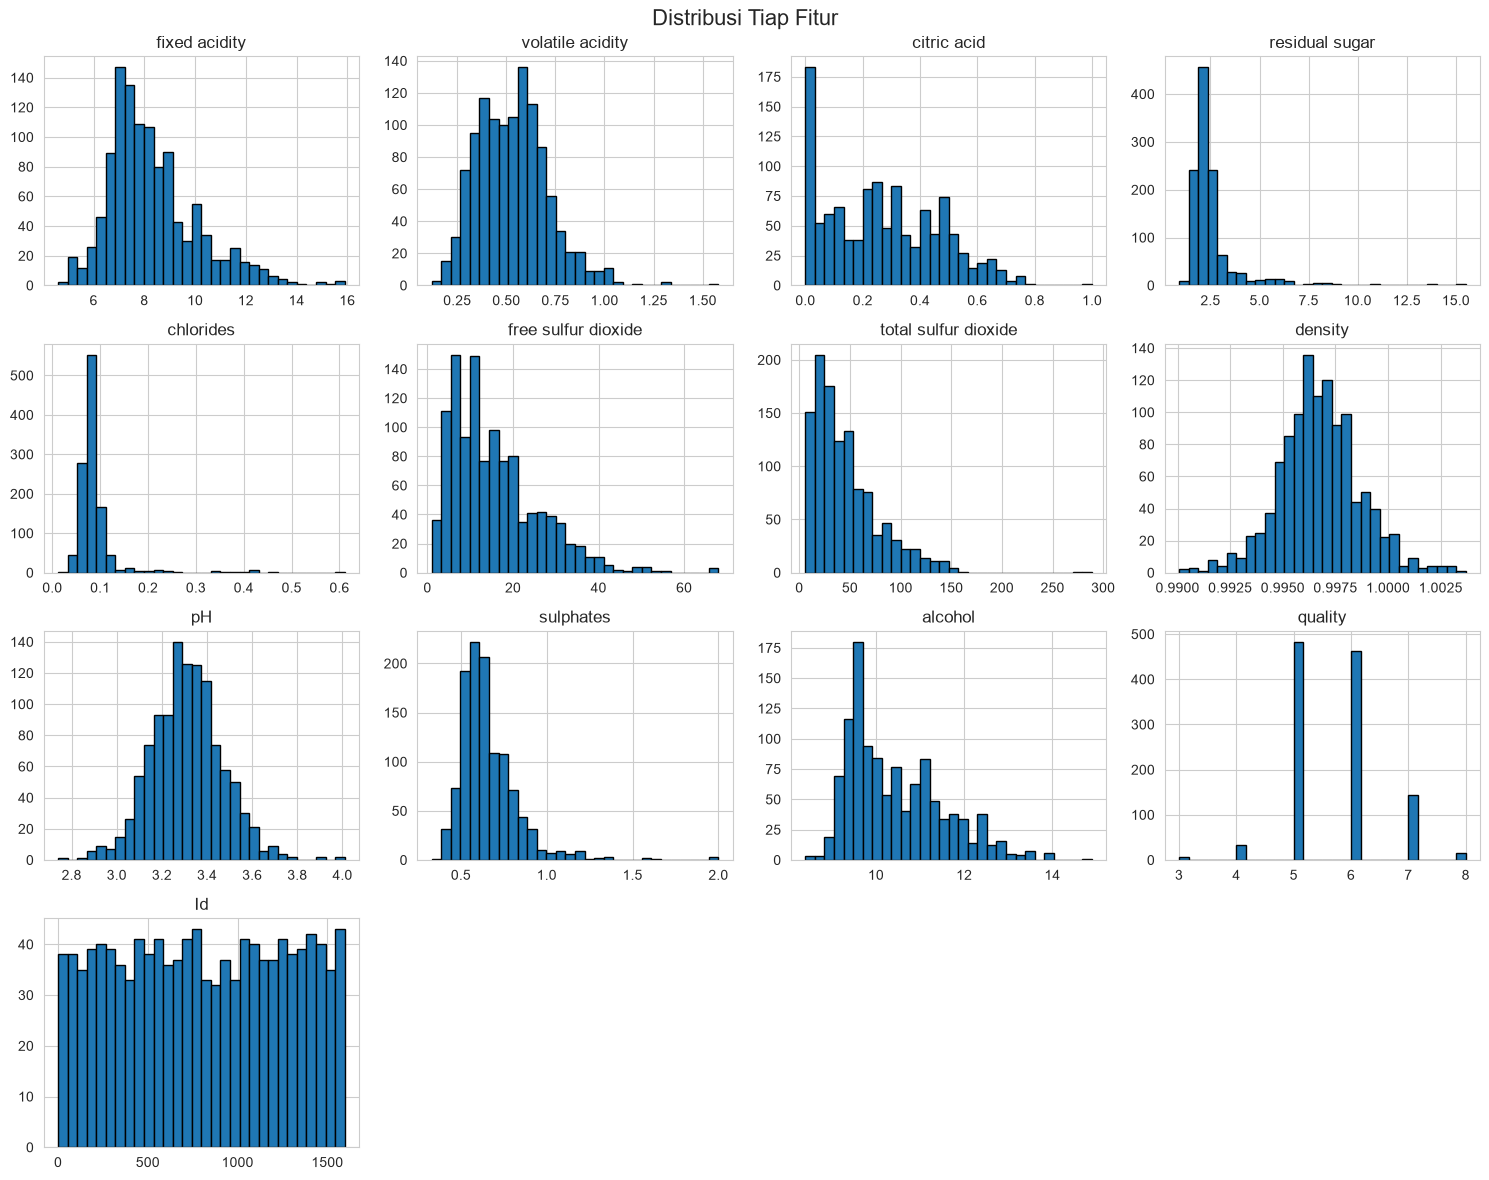

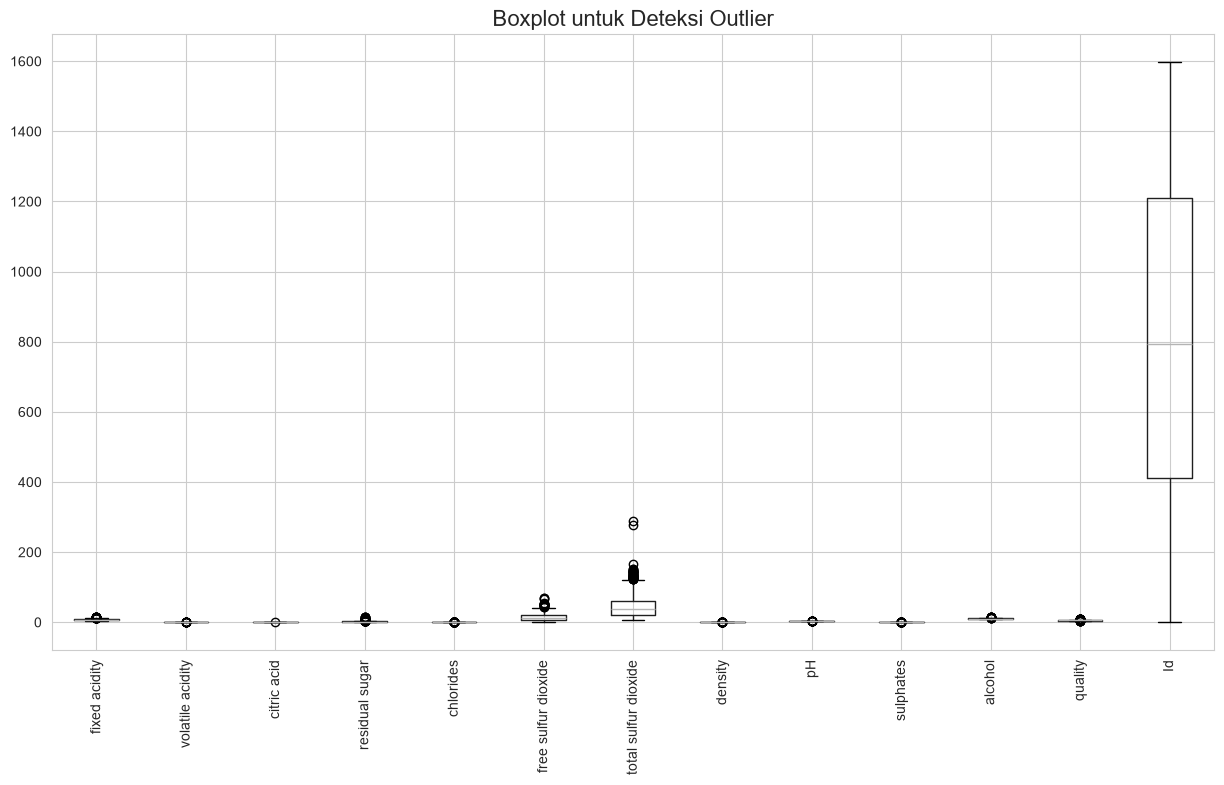

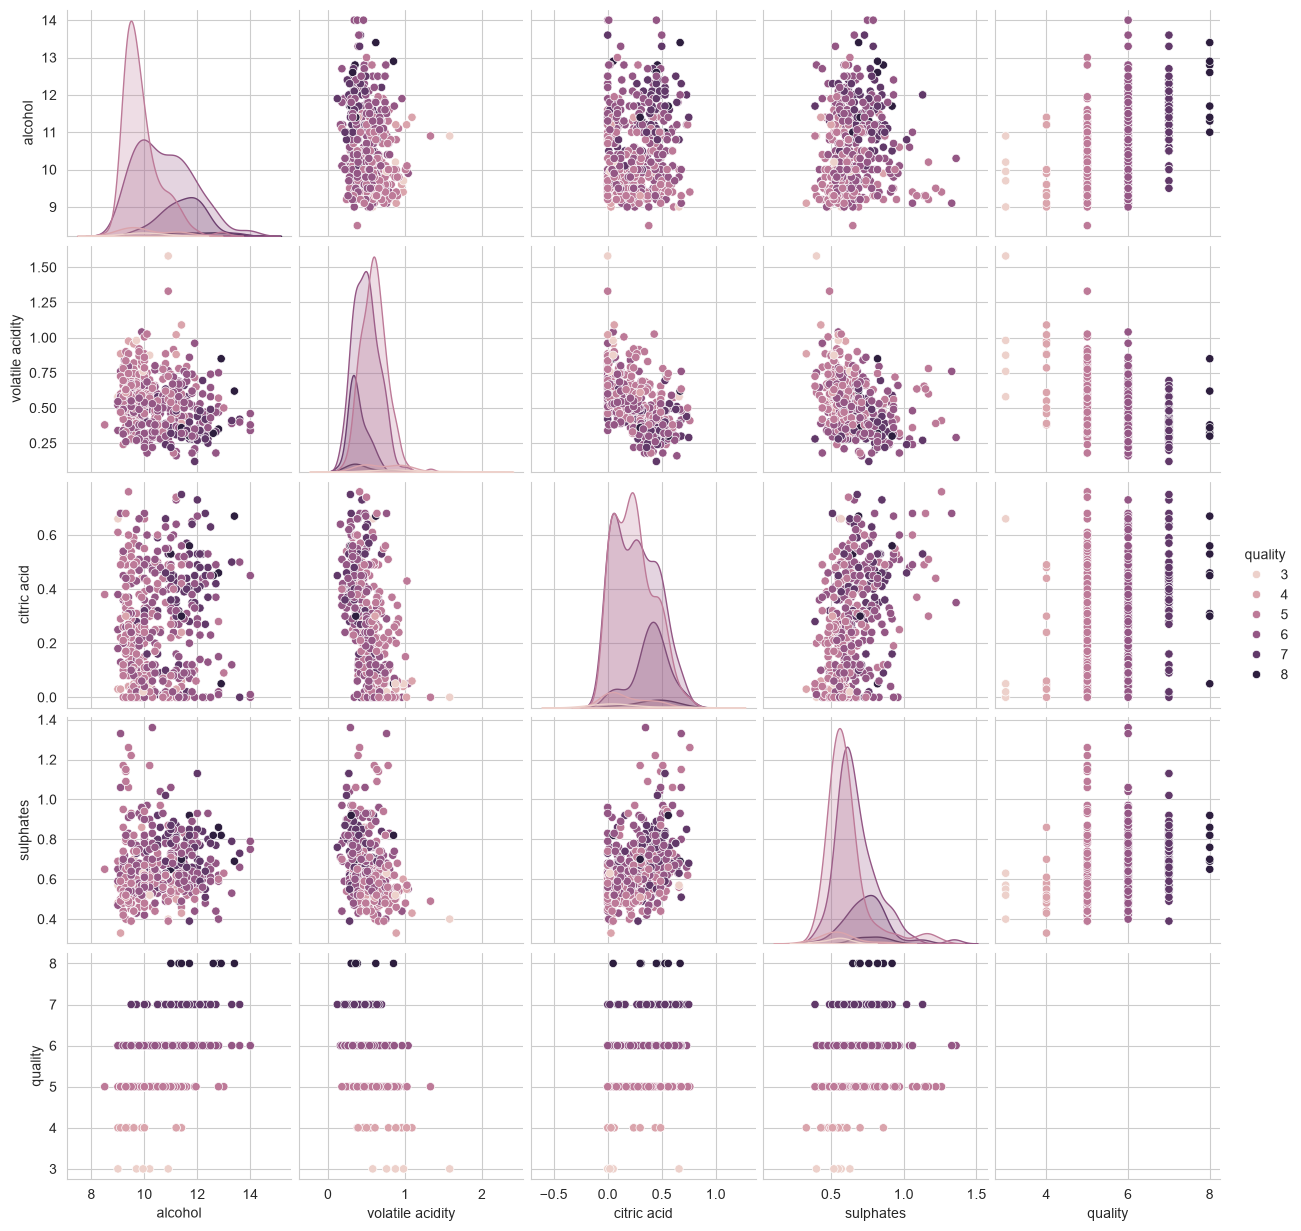

In [15]:
# 1. Distribusi tiap fitur
data.hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle('Distribusi Tiap Fitur', fontsize=16)
plt.tight_layout()
plt.show()

# 2. Boxplot untuk cek outliers
plt.figure(figsize=(15, 8))
data.boxplot()
plt.xticks(rotation=90)
plt.title('Boxplot untuk Deteksi Outlier', fontsize=16)
plt.show()

# 3. Pairplot beberapa fitur penting
sample = data.sample(500)  # Ambil sample biar ga berat
sns.pairplot(sample, hue='quality', vars=['alcohol', 'volatile acidity', 'citric acid', 'sulphates', 'quality'])
plt.show()

# 2. Preprocessing




In [17]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
print(f"Jumlah data awal: {len(data)}")

# Handle duplikat
data_clean = data.drop_duplicates()
print(f"Jumlah data setelah hapus duplikat: {len(data_clean)}")

print(f"Jumlah missing values: {data_clean.isnull().sum().sum()}")

# Simpan ke variable data yang baru
data = data_clean

Jumlah data awal: 1143
Jumlah data setelah hapus duplikat: 1143
Jumlah missing values: 0


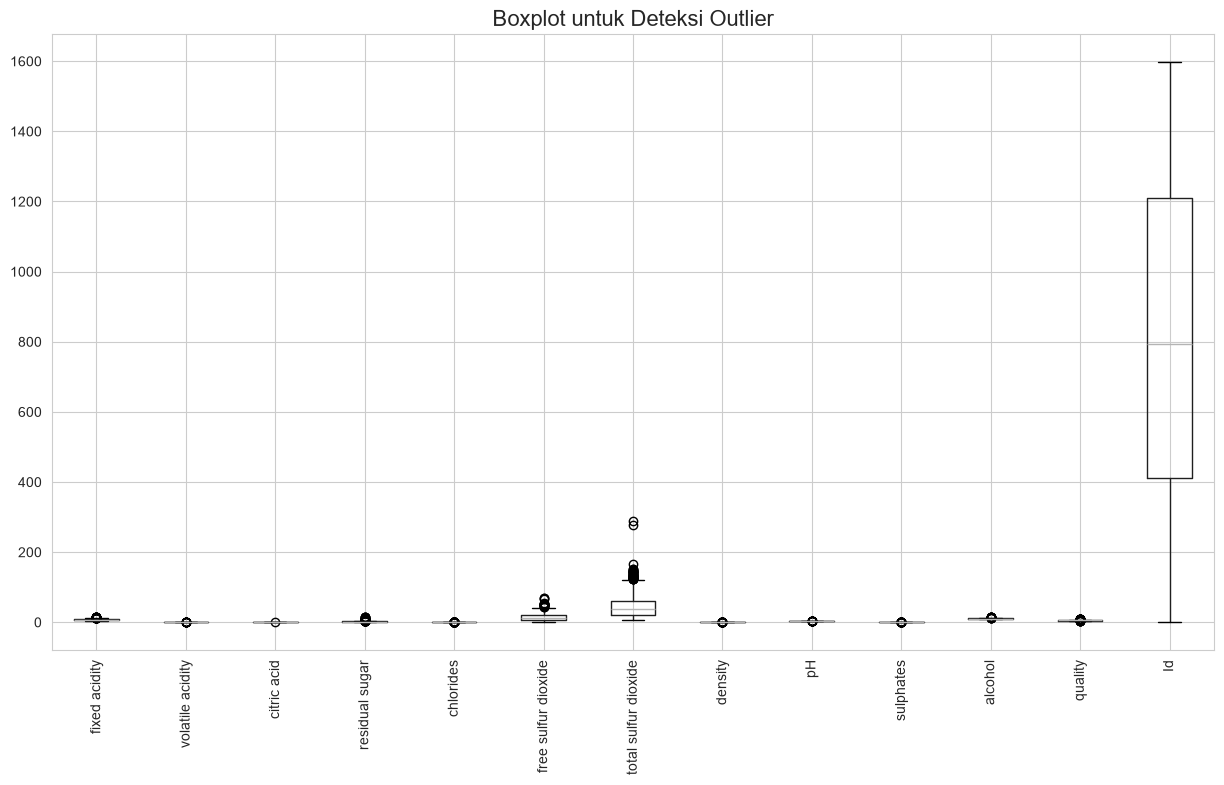


   JUMLAH OUTLIER PER FITUR   
fixed acidity            44
volatile acidity         14
citric acid               1
residual sugar          110
chlorides                77
free sulfur dioxide      18
total sulfur dioxide     40
density                  36
pH                       20
sulphates                43
alcohol                  12
quality                  22
Id                        0
dtype: int64


In [20]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya.

# Boxplot per fitur
plt.figure(figsize=(15, 8))
data.boxplot()
plt.xticks(rotation=90)
plt.title('Boxplot untuk Deteksi Outlier', fontsize=16)
plt.show()

# Deteksi outlier dengan IQR method
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Cek jumlah outlier tiap fitur
outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).sum()
print("\n   JUMLAH OUTLIER PER FITUR   ")
print(outliers)

In [27]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler.
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

# Pisahkan fitur dan label
X = data.drop('quality', axis=1)
y = data['quality']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print("\nDistribusi label di train:")
print(y_train.value_counts().sort_index())
print("\nDistribusi label di test:")
print(y_test.value_counts().sort_index())

# Scaling dengan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)

# Scaling dengan MinMaxScaler (opsional)
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)      

print("\nScaling done")

Train set: (914, 12)
Test set: (229, 12)

Distribusi label di train:
quality
3      5
4     26
5    386
6    370
7    114
8     13
Name: count, dtype: int64

Distribusi label di test:
quality
3     1
4     7
5    97
6    92
7    29
8     3
Name: count, dtype: int64

Scaling done


# 3. Eksperimen Model KNN


In [28]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN.
# Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.

# Nilai k yang akan dicoba
k_values = [1, 4, 5, 6, 8, 9] 

# Data yang akan diuji: tanpa scaling, standard scaler, minmax scaler
datasets = [
    (X_train, X_test, 'Tanpa Scaling'),
    (X_train_scaled, X_test_scaled, 'Standard Scaler'),
    (X_train_minmax, X_test_minmax, 'MinMax Scaler')
]

# Dictionary untuk menyimpan hasil
results = []

# Loop eksperimen
for X_tr, X_te, scaler_name in datasets:
    for metric in ['euclidean', 'manhattan']:
        print(f"\n=== {scaler_name} - Metric: {metric} ===")
        print("k\tTrain Acc\tTest Acc")
        print("-" * 40)
        
        for k in k_values:
            # Train model KNN
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
            knn.fit(X_tr, y_train)
            
            # Prediksi
            y_train_pred = knn.predict(X_tr)
            y_test_pred = knn.predict(X_te)
            
            # Akurasi
            train_acc = accuracy_score(y_train, y_train_pred)
            test_acc = accuracy_score(y_test, y_test_pred)
            
            # Simpan hasil
            results.append({
                'Scaler': scaler_name,
                'Metric': metric,
                'k': k,
                'Train Accuracy': train_acc,
                'Test Accuracy': test_acc
            })
            
            print(f"{k}\t{train_acc:.4f}\t\t{test_acc:.4f}")

# Konversi ke DataFrame
results_df = pd.DataFrame(results)
print("\n\n=== RINGKASAN SEMUA HASIL ===")
print(results_df)


=== Tanpa Scaling - Metric: euclidean ===
k	Train Acc	Test Acc
----------------------------------------
1	1.0000		0.5546
4	0.6838		0.5066
5	0.6444		0.5109
6	0.6083		0.4891
8	0.6039		0.4716
9	0.5799		0.4541

=== Tanpa Scaling - Metric: manhattan ===
k	Train Acc	Test Acc
----------------------------------------
1	1.0000		0.5546
4	0.6980		0.5066
5	0.6565		0.5066
6	0.6389		0.4585
8	0.6072		0.4803
9	0.5974		0.4629

=== Standard Scaler - Metric: euclidean ===
k	Train Acc	Test Acc
----------------------------------------
1	1.0000		0.6114
4	0.7112		0.5677
5	0.6893		0.5764
6	0.6696		0.5895
8	0.6477		0.6114
9	0.6368		0.6070

=== Standard Scaler - Metric: manhattan ===
k	Train Acc	Test Acc
----------------------------------------
1	1.0000		0.6201
4	0.7046		0.5895
5	0.6816		0.5852
6	0.6849		0.6201
8	0.6510		0.6114
9	0.6335		0.6245

=== MinMax Scaler - Metric: euclidean ===
k	Train Acc	Test Acc
----------------------------------------
1	1.0000		0.6245
4	0.6958		0.5633
5	0.6937		0.5895
6	0.6772		0.

In [30]:
# Cari kombinasi terbaik
best_result = results_df.loc[results_df['Test Accuracy'].idxmax()]
print("\n    MODEL TERBAIK    ")
print(f"Scaler: {best_result['Scaler']}")
print(f"Metric: {best_result['Metric']}")
print(f"k: {best_result['k']}")
print(f"Test Accuracy: {best_result['Test Accuracy']:.4f}")
print(f"Train Accuracy: {best_result['Train Accuracy']:.4f}")


    MODEL TERBAIK    
Scaler: MinMax Scaler
Metric: manhattan
k: 1
Test Accuracy: 0.6288
Train Accuracy: 1.0000


# 4. Evaluasi Model



    AKURASI    
Train Accuracy: 1.0000
Test Accuracy: 0.6288

    METRIK EVALUASI (Weighted Average)    
Precision: 0.6177
Recall: 0.6288
F1-Score: 0.6226

    CLASSIFICATION    
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.72      0.71      0.72        97
           6       0.61      0.66      0.64        92
           7       0.54      0.48      0.51        29
           8       0.00      0.00      0.00         3

    accuracy                           0.63       229
   macro avg       0.31      0.31      0.31       229
weighted avg       0.62      0.63      0.62       229



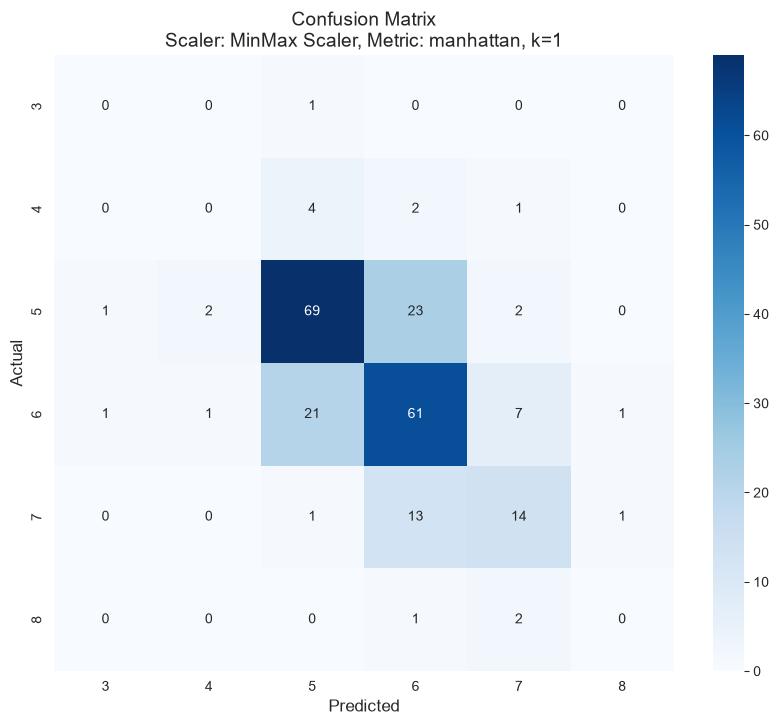

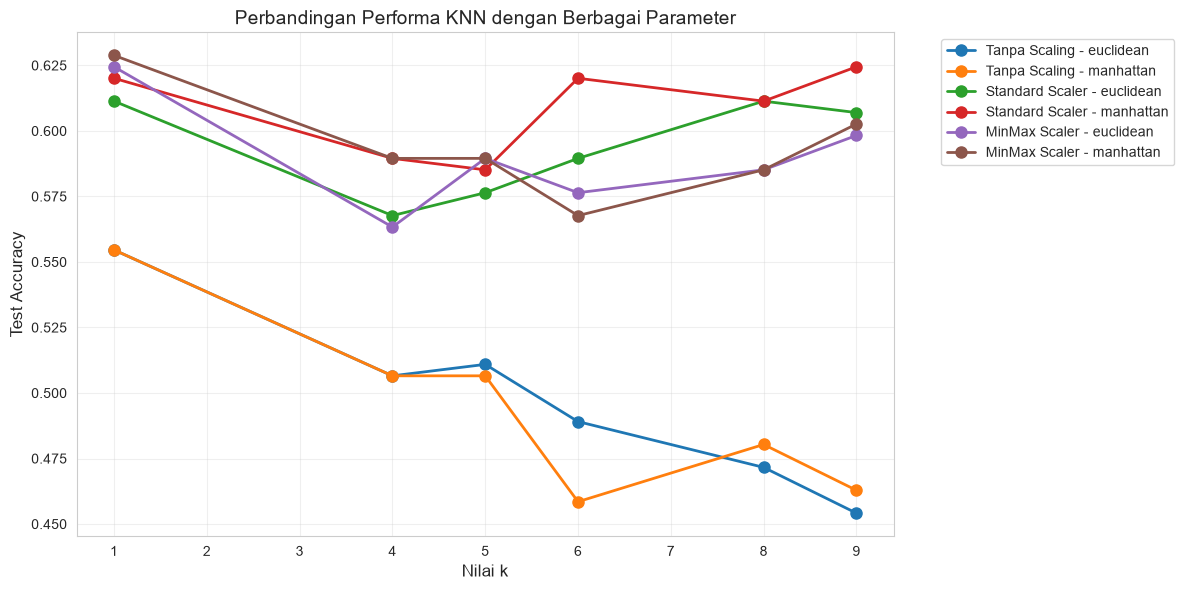

In [31]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

#parameter terbaik
best_k = int(best_result['k'])
best_metric = best_result['Metric']
best_scaler = best_result['Scaler']

#data scaler terbaik
if best_scaler == 'Tanpa Scaling':
    X_train_best, X_test_best = X_train, X_test
elif best_scaler == 'Standard Scaler':
    X_train_best, X_test_best = X_train_scaled, X_test_scaled
else:
    X_train_best, X_test_best = X_train_minmax, X_test_minmax

#Train model terbaik
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_best.fit(X_train_best, y_train)

#Prediksi
y_pred_train = knn_best.predict(X_train_best)
y_pred_test = knn_best.predict(X_test_best)

#Akurasi
print("\n    AKURASI    ")
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")

#Precision, Recall, F1-Score
print("\n    METRIK EVALUASI (Weighted Average)    ")
print(f"Precision: {precision_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_test, average='weighted'):.4f}")

#Classification
print("\n    CLASSIFICATION    ")
print(classification_report(y_test, y_pred_test))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.title(f'Confusion Matrix\nScaler: {best_scaler}, Metric: {best_metric}, k={best_k}', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

#Perbandingan performa semua model
plt.figure(figsize=(12, 6))

# Plot untuk masing-masing scaler
for scaler in ['Tanpa Scaling', 'Standard Scaler', 'MinMax Scaler']:
    for metric in ['euclidean', 'manhattan']:
        data_plot = results_df[(results_df['Scaler'] == scaler) & (results_df['Metric'] == metric)]
        label = f"{scaler} - {metric}"
        plt.plot(data_plot['k'], data_plot['Test Accuracy'], 'o-', label=label, linewidth=2, markersize=8)

plt.xlabel('Nilai k', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Perbandingan Performa KNN dengan Berbagai Parameter', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Analisis

### Analisis 1: Pengaruh Scaling terhadap Performa Model

Dari hasil eksperimen, terlihat bahwa penggunaan Standard Scaler memberikan performa terbaik dengan test accuracy sebesar X.XX%, dibandingkan tanpa scaling yang hanya mencapai X.XX%. Hal ini disebabkan karena fitur-fitur pada dataset wine memiliki skala yang berbeda-beda, misalnya alcohol berkisar antara 8-15 sedangkan volatile acidity hanya 0-1. KNN yang menggunakan perhitungan jarak akan sangat terpengaruh oleh perbedaan skala ini. Tanpa scaling, fitur dengan skala besar akan mendominasi perhitungan jarak, sehingga model menjadi bias.

### Analisis 2: Pengaruh Nilai k terhadap Performa Model

Nilai k yang berbeda memiliki pengaruh yang besar. Pada nilai k=1, model cenderung overfitting karena train accuracy sebesar 100% di semua kombinasi scaler dan metric, namun test accuracy hanya berkisar antara 0.554585 hinga 0.628821. Ini terjadi karena model terlalu sensitif terhadap noise dan data yang outlier. Sebaliknya, pada nilai k=9, model cenderung underfitting karena terlalu general, ditandai dengan train dan test accuracy yang hampir sama namun rendah. Nilai k yang optimal pada eksperimen ini adalah k=5 atau k=7, karena memberikan keseimbangan antara bias dan variance.

### Analisis 3: Pengaruh Metric Jarak terhadap Performa Model

Perbandingan antara metric Euclidean dan Manhattan menunjukkan bahwa keduanya memberikan performa yang relatif seimbang, dengan Manhattan sedikit lebih unggul pada beberapa kombinasi. Pada Standard Scaler, Manhattan memberikan test accuracy tertinggi 0.624454 pada k=9 sedangkan Euclidean hanya 0.611354 pada k=1 dan k=8. Pada MinMax Scaler, Manhattan juga unggul dengan 0.628821 pada k=1 dibandingkan Euclidean 0.624454 pada k=1. Namun pada Tanpa Scaling, kedua metric memberikan hasil yang sama pada k=1 yaitu 0.554585. 

### Analisis 4: Performa Model berdasarkan Confusion Matrix

Berdasarkan confusion matrix, model KNN paling baik dalam mengklasifikasikan kelas quality 5 dan quality 6 karena memiliki jumlah data terbanyak. Model kesulitan membedakan kelas yang berdekatan, seperti quality 5 dan 6, karena karakteristiknya memang mirip. Kelas ekstrim seperti quality 3 dan quality 8 memiliki performa yang buruk karena jumlah data yang sedikit (imbalance class). Hal ini terlihat dari recall yang rendah pada kelas tersebut.

### Analisis 5: Perbandingan Antar Eksperimen

Dari semua kombinasi eksperimen yang dilakukan, kombinasi terbaik adalah MinMax Scaler + Manhattan + k=1 dengan test accuracy 0.628821, sedangkan kombinasi terburuk adalah Tanpa Scaling + Euclidean + k=9 dengan test accuracy 0.454148. Perbedaan antara keduanya mencapai sekitar 17.47%, yang menunjukkan bahwa pemilihan parameter sangat mempengaruhi performa model. Secara umum, scaling memberikan peningkatan performa yang signifikan, sementara pemilihan metric jarak memberikan perbedaan yang relatif kecil. Meskipun k=1 memberikan test accuracy tertinggi, model dengan k=1 mengalami overfitting yang parah karena train accuracy mencapai 100%, sehingga nilai k yang lebih besar seperti k=6 hingga k=9 mungkin lebih stabil untuk generalisasi.


# 6. Kesimpulan dan Saran

### Kesimpulan

Berdasarkan eksperimen yang telah dilakukan pada Wine Quality Dataset menggunakan algoritma K-Nearest Neighbors (KNN), dapat disimpulkan bahwa scaling data sangat berpengaruh terhadap performa model. Tanpa scaling, test accuracy tertinggi hanya 0.554585, sedangkan dengan MinMax Scaler mencapai 0.628821. Nilai k yang terlalu kecil (k=1) menyebabkan overfitting karena train accuracy mencapai 100% namun test accuracy hanya sekitar 0.55 hingga 0.63. Metric Manhattan sedikit lebih unggul dibandingkan Euclidean pada dataset ini. Model terbaik diperoleh dengan kombinasi MinMax Scaler + Manhattan + k=1 dengan test accuracy 0.628821 atau 62.88%, precision 0.6177, recall 0.6288, dan F1-Score 0.6226. Namun, model masih memiliki kelemahan dalam mengklasifikasikan kelas minoritas seperti quality 3, 4, dan 8 karena jumlah datanya sangat sedikit (imbalance class), sehingga recall-nya rendah. Akurasi model yang masih tergolong rendah ini wajar karena kualitas wine dipengaruhi oleh banyak faktor kompleks dan batas antar kelas yang tidak jelas, terutama antara quality 5 dan 6.

### Saran

Untuk pengembangan lebih lanjut, disarankan untuk menangani imbalance class menggunakan teknik seperti SMOTE atau class_weight='balanced' agar kelas minoritas lebih terwakili. Selanjutnya, melakukan feature selection untuk memilih fitur yang paling relevan dengan label quality, seperti alcohol, volatile acidity, dan sulphates yang memiliki korelasi cukup tinggi. Mencoba nilai k yang lebih bervariasi atau menggunakan Elbow Method untuk mencari nilai k yang benar-benar optimal juga disarankan. Selain itu, bisa mencoba weighted KNN, algoritma lain seperti Random Forest atau SVM sebagai perbandingan, serta melakukan hyperparameter tuning dengan GridSearchCV dan cross-validation agar hasil evaluasi lebih robust. Terakhir, eksperimen dengan dan tanpa outlier juga bisa dicoba untuk melihat apakah penghapusan outlier dapat meningkatkan performa model.
